# Bitcoin Market Sentiment & Trader Performance Analysis
### Exploring the Relationship Between Fear/Greed Index and Hyperliquid Trader Behavior (2024)

---
**Datasets:**  
- `fear_greed_index.csv` — Daily Bitcoin Fear & Greed Index (2018–2025)  
- `historical_data.csv` — Hyperliquid Perpetual Trade Logs (Jan–Dec 2024, 90,199 trades, 16 traders)  

**Goal:** Uncover whether market sentiment (fear vs. greed) influences trader profitability, risk-taking, and win rates.


## 1. Setup & Imports

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plotting aesthetics
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#3a3d4d',
    'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0',
    'xtick.color': '#b0b0b0',
    'ytick.color': '#b0b0b0',
    'grid.color': '#2a2d3d',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

SENTIMENT_COLORS = {
    'Extreme Fear': '#e74c3c',
    'Fear':         '#e67e22',
    'Neutral':      '#f1c40f',
    'Greed':        '#2ecc71',
    'Extreme Greed':'#1abc9c',
}
SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
print("Imports successful ")


Imports successful 


## 2. Data Loading & Initial Inspection

In [19]:
fg_raw = pd.read_csv('/content/fear_greed_index.csv')
tr_raw = pd.read_csv('/content/historical_data.csv')

print("=== Fear & Greed Index ===")
print(f"Shape: {fg_raw.shape}")
display(fg_raw.head(3))

print("\n=== Trader Historical Data ===")
print(f"Shape: {tr_raw.shape}")
display(tr_raw.head(3))

=== Fear & Greed Index ===
Shape: (2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03



=== Trader Historical Data ===
Shape: (209764, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


## 3. Data Cleaning

### 3.1 Fear & Greed Index


In [20]:
# Fear & Greed cleaning
fg = fg_raw.copy()

# Parse date
fg['date'] = pd.to_datetime(fg['date'])
fg = fg.sort_values('date').drop_duplicates('date').reset_index(drop=True)

# Check missing values
print("Missing values:\n", fg.isnull().sum())
print("\nDate range:", fg['date'].min().date(), "→", fg['date'].max().date())
print("Classification distribution:")
print(fg['classification'].value_counts())

# Ordered categorical for sorting
fg['classification'] = pd.Categorical(
    fg['classification'], categories=SENTIMENT_ORDER, ordered=True)


Missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Date range: 2018-02-01 → 2025-05-02
Classification distribution:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


### 3.2 Historical Trader Data

In [21]:
# Trader data cleaning
tr = tr_raw.copy()

# Standardize column names
tr.columns = [c.strip().replace(' ', '_') for c in tr.columns]

# Parse timestamp — format: DD-MM-YYYY HH:MM
tr['Timestamp_IST'] = pd.to_datetime(tr['Timestamp_IST'], format='%d-%m-%Y %H:%M', errors='coerce')
tr['date'] = tr['Timestamp_IST'].dt.normalize()

# Missing values
print("Missing values:\n", tr.isnull().sum())

# Coerce numeric
for col in ['Closed_PnL', 'Size_USD', 'Execution_Price', 'Fee', 'Size_Tokens']:
    tr[col] = pd.to_numeric(tr[col], errors='coerce').fillna(0)

# Shorten account addresses for readability
tr['account_short'] = tr['Account'].str[:8] + '…'

print(f"\nDate range: {tr['date'].min().date()} → {tr['date'].max().date()}")
print(f"Unique accounts: {tr['Account'].nunique()}")
print(f"Unique coins: {tr['Coin'].nunique()}")
print(f"Trade directions: {tr['Direction'].unique()}")


Missing values:
 Account             0
Coin                0
Execution_Price     0
Size_Tokens         0
Size_USD            0
Side                0
Timestamp_IST       0
Start_Position      0
Direction           0
Closed_PnL          0
Transaction_Hash    0
Order_ID            0
Crossed             0
Fee                 1
Trade_ID            1
Timestamp           1
date                0
dtype: int64

Date range: 2023-05-01 → 2025-05-01
Unique accounts: 32
Unique coins: 246
Trade directions: ['Buy' 'Sell' 'Open Long' 'Close Long' 'Spot Dust Conversion' 'Open Short'
 'Close Short' 'Long > Short' 'Short > Long' 'Auto-Deleveraging'
 'Liquidated Isolated Short' 'Settlement']


## 4. Merging Datasets

In [22]:
# Merge on date
merged = tr.merge(fg[['date','value','classification']], on='date', how='left')

missing_sent = merged['classification'].isnull().sum()
print(f"Trades without matched sentiment: {missing_sent} ({missing_sent/len(merged)*100:.1f}%)")

# Drop unmatched rows (should be minimal)
merged = merged.dropna(subset=['classification'])
merged['classification'] = pd.Categorical(
    merged['classification'], categories=SENTIMENT_ORDER, ordered=True)

print(f"\nFinal merged shape: {merged.shape}")
print("\nTrade counts per sentiment:")
print(merged['classification'].value_counts().sort_index())


Trades without matched sentiment: 6 (0.0%)

Final merged shape: (209758, 20)

Trade counts per sentiment:
classification
Extreme Fear     20891
Fear             61526
Neutral          37607
Greed            49742
Extreme Greed    39992
Name: count, dtype: int64


## 5. PnL Analysis by Market Sentiment

In [23]:
# 5.1 Aggregate PnL by sentiment
# Closed trades only (non-zero PnL)
closed = merged[merged['Closed_PnL'] != 0].copy()

pnl_by_sent = (
    closed.groupby('classification', observed=True)['Closed_PnL']
    .agg(
        Total_PnL='sum',
        Mean_PnL='mean',
        Median_PnL='median',
        Trade_Count='count',
        Std_PnL='std'
    )
    .reindex(SENTIMENT_ORDER)
    .round(2)
)
pnl_by_sent['Win_Rate_%'] = (
    closed.groupby('classification', observed=True)['Closed_PnL']
    .apply(lambda x: (x > 0).mean() * 100)
    .reindex(SENTIMENT_ORDER)
    .round(1)
)
display(pnl_by_sent)


,Total_PnL,Mean_PnL,Median_PnL,Trade_Count,Std_PnL,Win_Rate_%
classification,,,,,,
Extreme Fear,705130.25,69.86,5.67,10094,1652.57,75.5
Fear,3415375.19,115.18,6.44,29652,1331.04,87.6
Neutral,1292920.68,71.20,4.58,18159,743.21,82.4
Greed,1782297.73,71.47,4.87,24939,1475.21,77.0
Extreme Greed,2715171.31,130.21,8.53,20853,1058.13,89.2


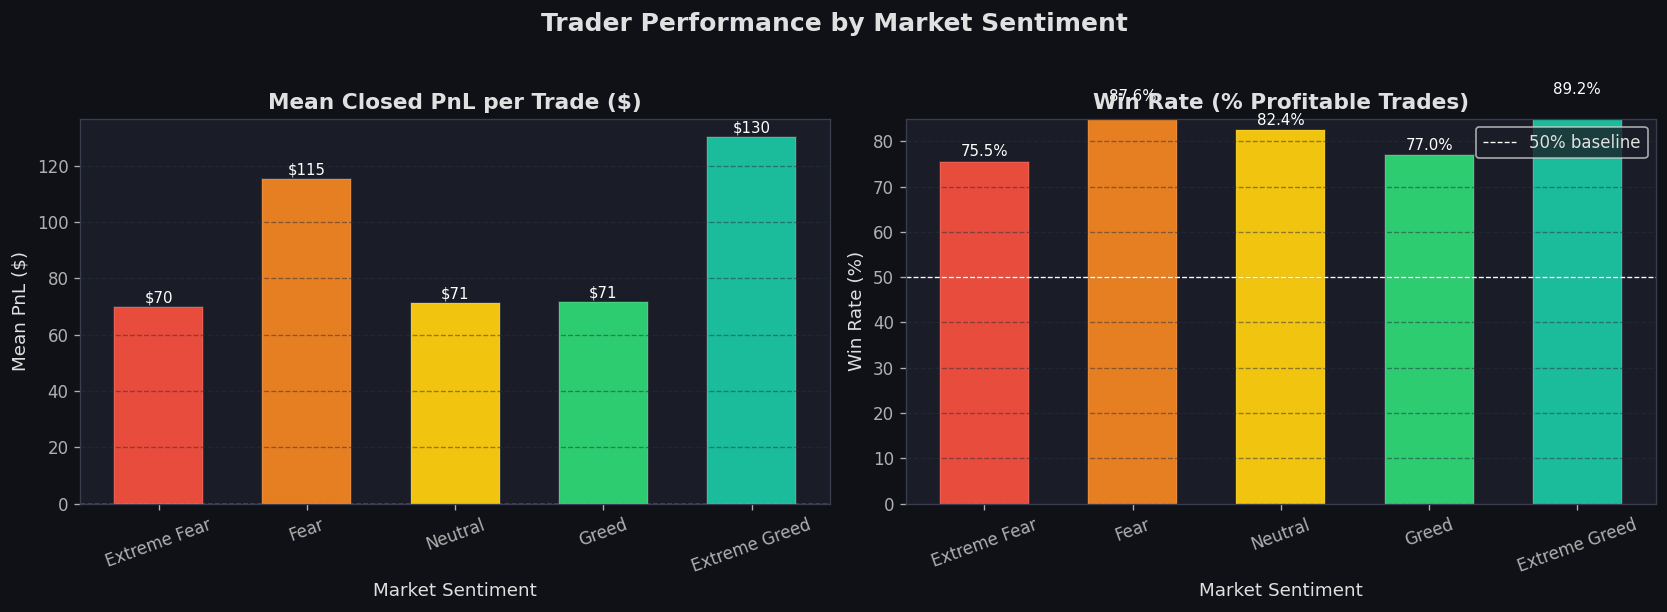

Figure saved.


In [24]:
# 5.2 Plot: Mean PnL & Win Rate by Sentiment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Trader Performance by Market Sentiment', fontsize=15, fontweight='bold', y=1.01)

# Mean PnL bar
ax1 = axes[0]
colors = [SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER]
bars = ax1.bar(SENTIMENT_ORDER, pnl_by_sent['Mean_PnL'], color=colors, width=0.6, edgecolor='#ffffff22')
ax1.axhline(0, color='white', lw=0.8, ls='--')
ax1.set_title('Mean Closed PnL per Trade ($)', fontweight='bold')
ax1.set_xlabel('Market Sentiment')
ax1.set_ylabel('Mean PnL ($)')
for bar, val in zip(bars, pnl_by_sent['Mean_PnL']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=9, color='white')
ax1.tick_params(axis='x', rotation=20)
ax1.grid(axis='y')

# Win Rate bar
ax2 = axes[1]
bars2 = ax2.bar(SENTIMENT_ORDER, pnl_by_sent['Win_Rate_%'], color=colors, width=0.6, edgecolor='#ffffff22')
ax2.axhline(50, color='white', lw=0.8, ls='--', label='50% baseline')
ax2.set_title('Win Rate (% Profitable Trades)', fontweight='bold')
ax2.set_xlabel('Market Sentiment')
ax2.set_ylabel('Win Rate (%)')
ax2.set_ylim(0, 85)
ax2.legend(facecolor='#1a1d27')
for bar, val in zip(bars2, pnl_by_sent['Win_Rate_%']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='white')
ax2.tick_params(axis='x', rotation=20)
ax2.grid(axis='y')

plt.tight_layout()
plt.savefig('/content/fig_pnl_winrate.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Figure saved.")

## 6. Trading Activity & Volume by Sentiment

In [25]:
# Volume & Activity
vol_by_sent = (
    merged.groupby('classification', observed=True)
    .agg(
        Total_Volume_USD=('Size_USD', 'sum'),
        Avg_Trade_Size=('Size_USD', 'mean'),
        Trade_Count=('Size_USD', 'count'),
    )
    .reindex(SENTIMENT_ORDER)
    .round(0)
)
# Normalize by trading days in each sentiment (fairer comparison)
days_per_sent = merged.groupby('classification', observed=True)['date'].nunique().reindex(SENTIMENT_ORDER)
vol_by_sent['Trading_Days'] = days_per_sent
vol_by_sent['Avg_Daily_Volume'] = (vol_by_sent['Total_Volume_USD'] / vol_by_sent['Trading_Days']).round(0)
display(vol_by_sent)


,Total_Volume_USD,Avg_Trade_Size,Trade_Count,Trading_Days,Avg_Daily_Volume
classification,,,,,
Extreme Fear,111306983.0,5328.0,20891,14,7950499.0
Fear,481994408.0,7834.0,61526,91,5296642.0
Neutral,180136063.0,4790.0,37607,67,2688598.0
Greed,283921329.0,5708.0,49742,193,1471095.0
Extreme Greed,124465165.0,3112.0,39992,114,1091800.0


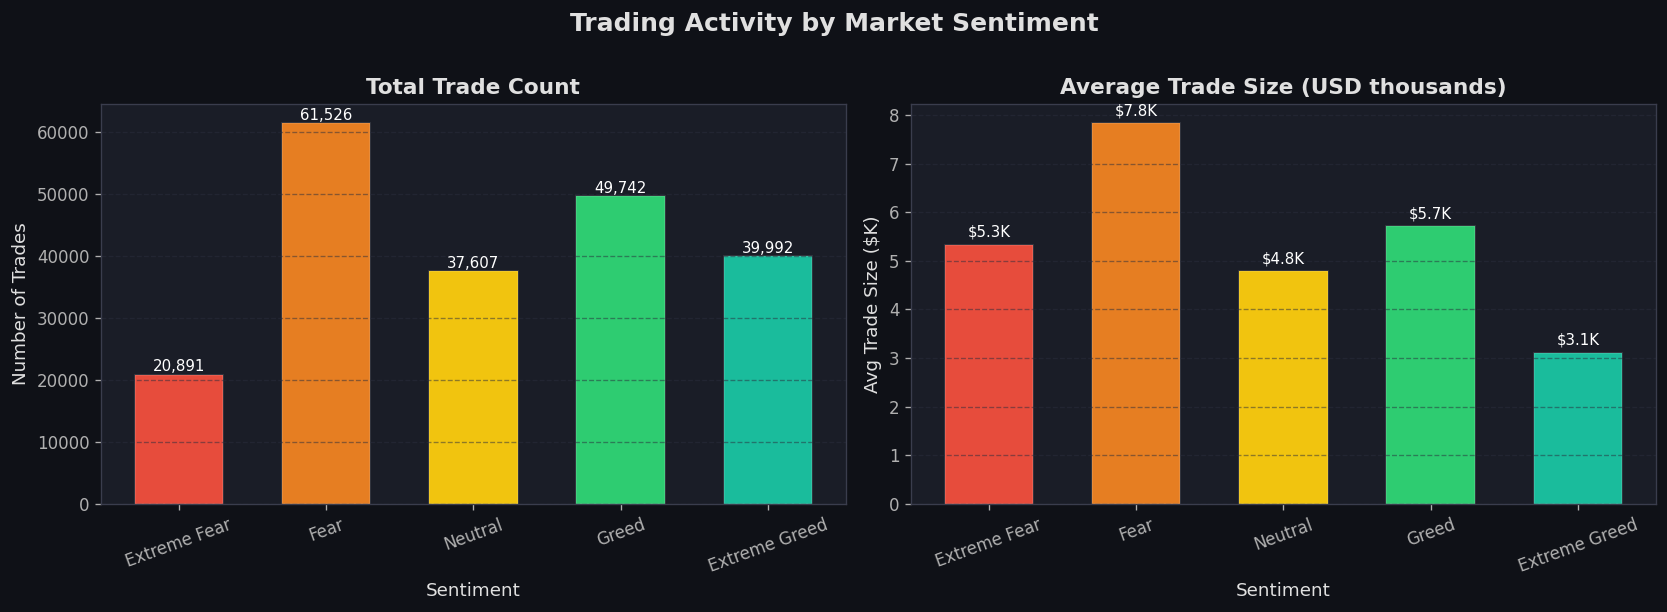

In [28]:
# Plot: Trade Count + Avg Trade Size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Trading Activity by Market Sentiment', fontsize=15, fontweight='bold', y=1.01)

ax1 = axes[0]
bars = ax1.bar(SENTIMENT_ORDER, vol_by_sent['Trade_Count'], color=colors, width=0.6, edgecolor='#ffffff22')
ax1.set_title('Total Trade Count', fontweight='bold')
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Number of Trades')
for bar, val in zip(bars, vol_by_sent['Trade_Count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{int(val):,}', ha='center', va='bottom', fontsize=9, color='white')
ax1.tick_params(axis='x', rotation=20)
ax1.grid(axis='y')

ax2 = axes[1]
bars2 = ax2.bar(SENTIMENT_ORDER, vol_by_sent['Avg_Trade_Size']/1000, color=colors, width=0.6, edgecolor='#ffffff22')
ax2.set_title('Average Trade Size (USD thousands)', fontweight='bold')
ax2.set_xlabel('Sentiment')
ax2.set_ylabel('Avg Trade Size ($K)')
for bar, val in zip(bars2, vol_by_sent['Avg_Trade_Size']/1000):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'${val:,.1f}K', ha='center', va='bottom', fontsize=9, color='white')
ax2.tick_params(axis='x', rotation=20)
ax2.grid(axis='y')

plt.tight_layout()
plt.savefig('/content/fig_activity.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 7. Long vs Short Positioning by Sentiment

In [29]:
# Direction Analysis
directional = merged[merged['Direction'].isin(['Open Long','Open Short','Buy','Sell'])].copy()
# Unify: BUY/Open Long = Long; SELL/Open Short = Short
directional['position_type'] = directional['Direction'].map({
    'Open Long': 'Long', 'Buy': 'Long',
    'Open Short': 'Short', 'Sell': 'Short'
})

pos_mix = (
    directional.groupby(['classification','position_type'], observed=True)['Size_USD']
    .count().unstack(fill_value=0)
    .reindex(SENTIMENT_ORDER)
)
pos_mix['Long_%'] = (pos_mix.get('Long',0) / (pos_mix.get('Long',0) + pos_mix.get('Short',0)) * 100).round(1)
display(pos_mix)


position_type,Long,Short,Long_%
classification,,,
Extreme Fear,7713,4118,65.2
Fear,20947,14130,59.7
Neutral,13028,8699,60.0
Greed,13151,17404,43.0
Extreme Greed,11432,14827,43.5


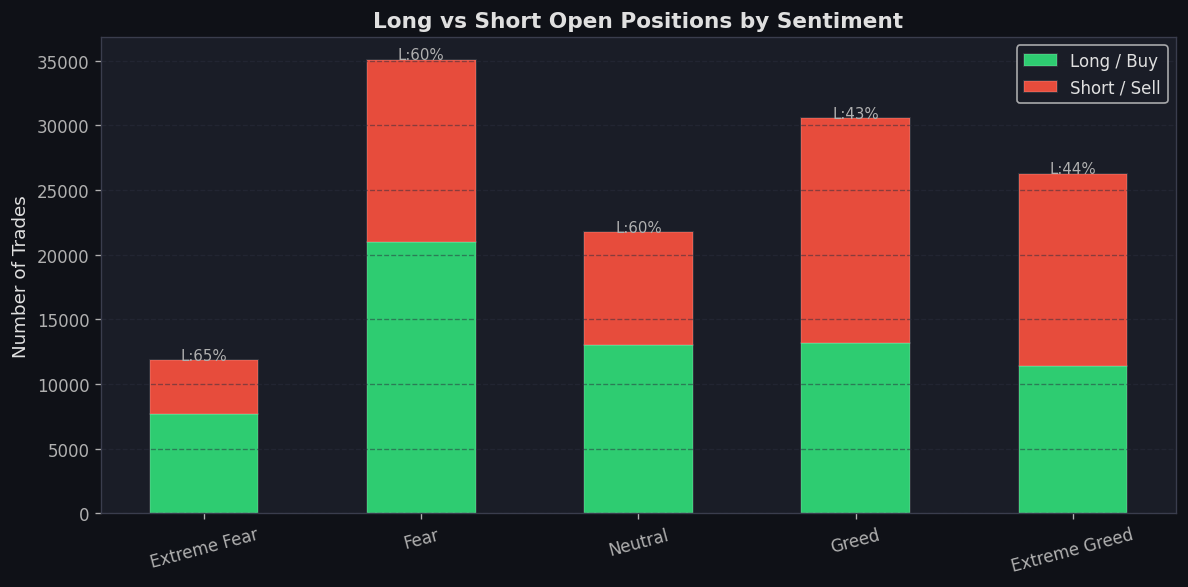

In [31]:
# Plot: Long vs Short stacked
fig, ax = plt.subplots(figsize=(10, 5))
longs  = pos_mix.get('Long', pd.Series([0]*5, index=SENTIMENT_ORDER))
shorts = pos_mix.get('Short', pd.Series([0]*5, index=SENTIMENT_ORDER))
x = np.arange(len(SENTIMENT_ORDER))
ax.bar(x, longs,  label='Long / Buy',   color='#2ecc71', width=0.5, edgecolor='#ffffff22')
ax.bar(x, shorts, label='Short / Sell', color='#e74c3c', width=0.5, edgecolor='#ffffff22', bottom=longs)

# Long% labels
for i, (l, s) in enumerate(zip(longs, shorts)):
    total = l + s
    if total > 0:
        ax.text(i, total + 50, f'L:{l/(total)*100:.0f}%', ha='center', fontsize=9, color='#b0b0b0')

ax.set_xticks(x)
ax.set_xticklabels(SENTIMENT_ORDER, rotation=15)
ax.set_title('Long vs Short Open Positions by Sentiment', fontweight='bold')
ax.set_ylabel('Number of Trades')
ax.legend(facecolor='#1a1d27')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('/content/fig_longshort.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 8. Daily Cumulative PnL vs Fear & Greed Index

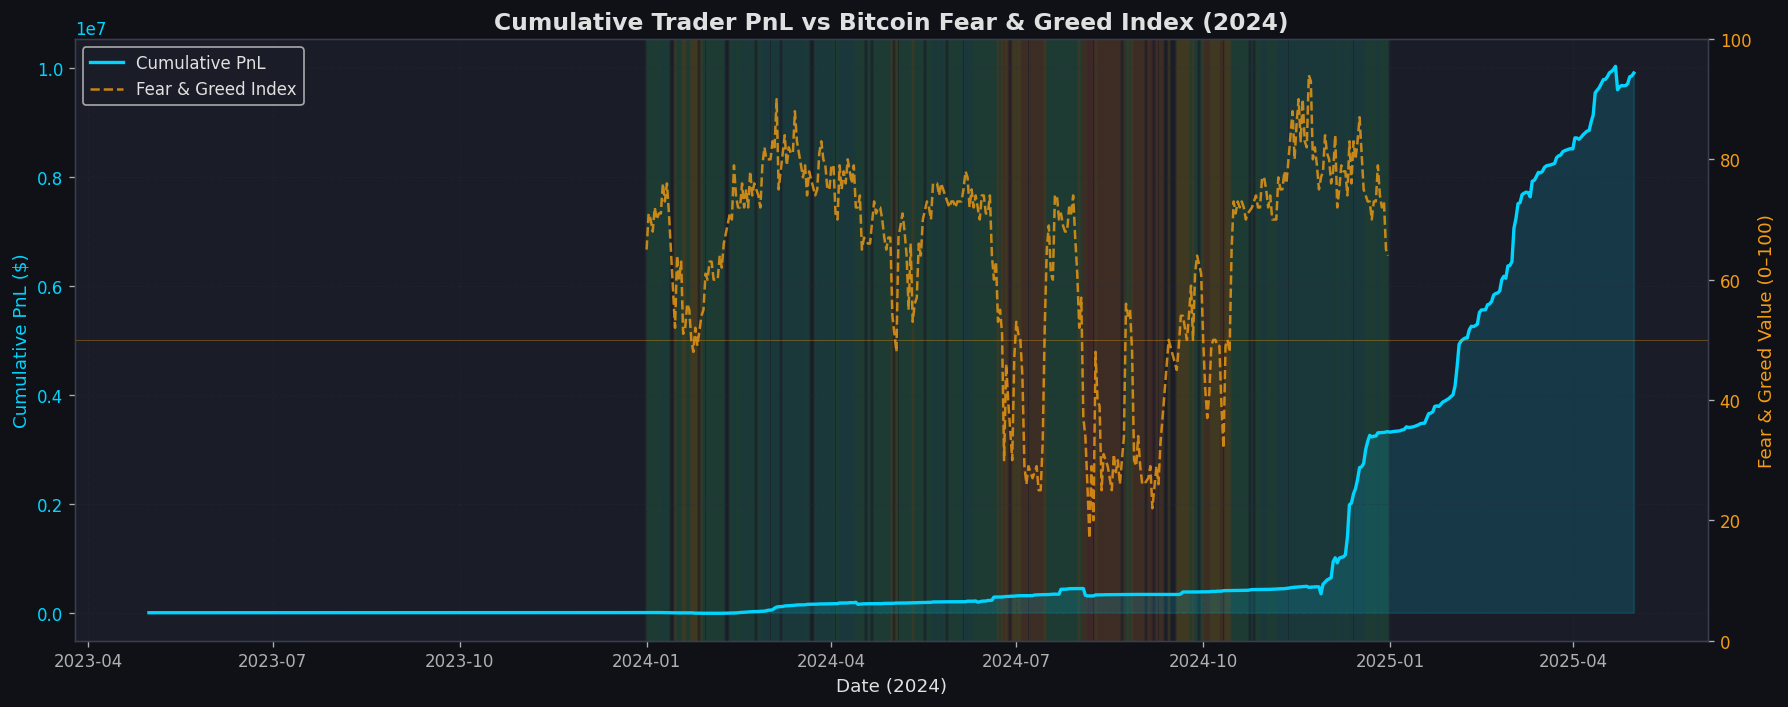

In [33]:
# Daily PnL timeseries overlaid with F&G
daily_pnl = (
    merged.groupby('date')['Closed_PnL'].sum().reset_index()
)
daily_pnl['Cumulative_PnL'] = daily_pnl['Closed_PnL'].cumsum()

# Merge daily FG value
daily_merged = daily_pnl.merge(
    fg[fg['date'].dt.year == 2024][['date','value','classification']],
    on='date', how='left'
)

fig, ax1 = plt.subplots(figsize=(15, 6))
ax2 = ax1.twinx()

# Background sentiment coloring
for i, row in daily_merged.iterrows():
    if pd.notna(row['classification']):
        ax1.axvspan(row['date'] - pd.Timedelta(hours=12),
                    row['date'] + pd.Timedelta(hours=12),
                    alpha=0.07,
                    color=SENTIMENT_COLORS.get(str(row['classification']), '#888888'))

ax1.plot(daily_merged['date'], daily_merged['Cumulative_PnL'],
         color='#00d4ff', lw=2, label='Cumulative PnL')
ax1.fill_between(daily_merged['date'], daily_merged['Cumulative_PnL'],
                 alpha=0.15, color='#00d4ff')
ax1.set_ylabel('Cumulative PnL ($)', color='#00d4ff')
ax1.tick_params(axis='y', labelcolor='#00d4ff')
ax1.set_xlabel('Date (2024)')

ax2.plot(daily_merged['date'], daily_merged['value'],
         color='#f39c12', lw=1.5, alpha=0.8, label='Fear & Greed Index', linestyle='--')
ax2.set_ylabel('Fear & Greed Value (0–100)', color='#f39c12')
ax2.tick_params(axis='y', labelcolor='#f39c12')
ax2.set_ylim(0, 100)
ax2.axhline(50, color='#f39c12', lw=0.5, alpha=0.4)

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', facecolor='#1a1d27')

ax1.set_title('Cumulative Trader PnL vs Bitcoin Fear & Greed Index (2024)', fontweight='bold', fontsize=14)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/fig_timeseries.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 9. Per-Account Performance Breakdown

In [34]:
# Per-account PnL
acct_pnl = (
    closed.groupby('account_short')['Closed_PnL']
    .agg(Total_PnL='sum', Trade_Count='count', Win_Rate=lambda x: (x>0).mean()*100)
    .sort_values('Total_PnL', ascending=False)
    .round(2)
)
display(acct_pnl)


,Total_PnL,Trade_Count,Win_Rate
account_short,,,
0xb1231a…,2143382.60,6279,79.10
0x083384…,1600229.82,1732,79.27
0xbaaaf6…,940163.81,9997,99.12
0x513b86…,840422.56,5482,89.55
0xbee170…,836080.55,22551,76.31
0x4acb90…,677747.05,2233,94.85
0x430f09…,416541.87,599,100.00
0x75f7ee…,379095.41,8660,92.63
0x72c6a4…,360539.51,558,77.42


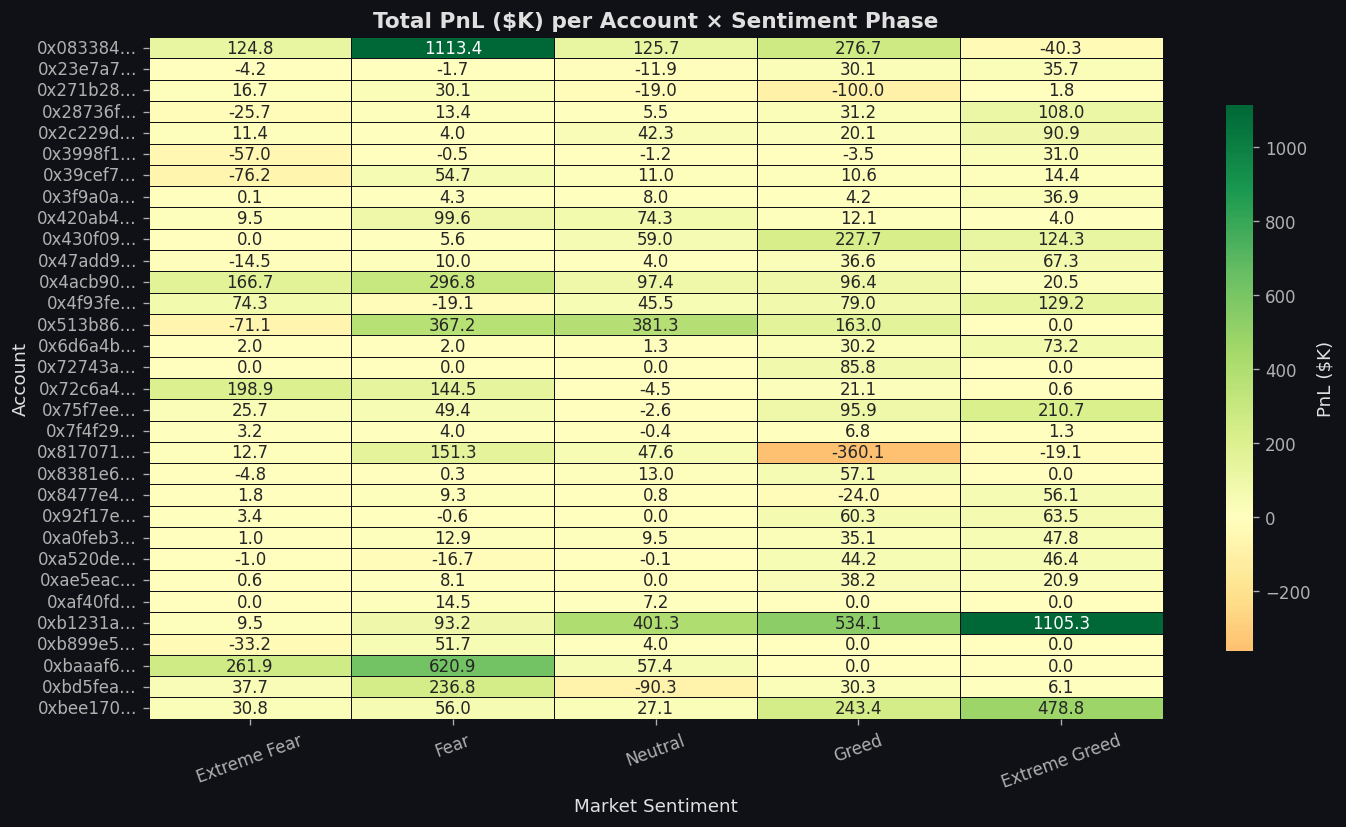

In [36]:
#  Plot: Account PnL heatmap by sentiment
pivot = (
    closed.groupby(['account_short','classification'], observed=True)['Closed_PnL']
    .sum().unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER)
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    pivot / 1000,
    annot=True, fmt='.1f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, linecolor='#0f1117',
    cbar_kws={'label': 'PnL ($K)', 'shrink': 0.8},
    ax=ax
)
ax.set_title('Total PnL ($K) per Account × Sentiment Phase', fontweight='bold', fontsize=13)
ax.set_xlabel('Market Sentiment')
ax.set_ylabel('Account')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('/content/fig_heatmap.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 10. PnL Distribution: Fear vs Greed

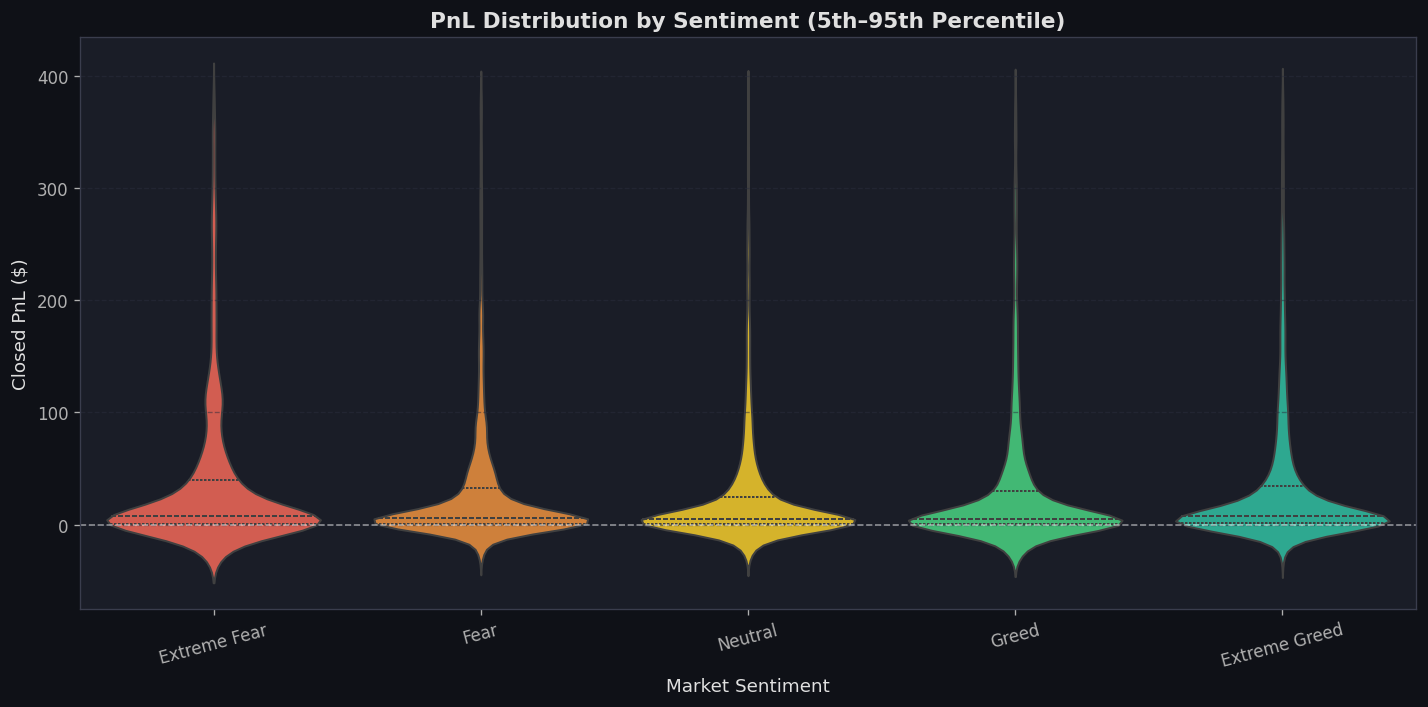

In [38]:
# Box + strip plot
# Filter outliers for visual clarity (keep 5th–95th percentile)
p5 = closed['Closed_PnL'].quantile(0.05)
p95 = closed['Closed_PnL'].quantile(0.95)
clipped = closed[(closed['Closed_PnL'] >= p5) & (closed['Closed_PnL'] <= p95)].copy()

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(
    data=clipped, x='classification', y='Closed_PnL',
    order=SENTIMENT_ORDER,
    palette=SENTIMENT_COLORS,
    inner='quartile',
    linewidth=1.2,
    ax=ax
)
ax.axhline(0, color='white', lw=1, ls='--', alpha=0.5)
ax.set_title('PnL Distribution by Sentiment (5th–95th Percentile)', fontweight='bold')
ax.set_xlabel('Market Sentiment')
ax.set_ylabel('Closed PnL ($)')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('/content/fig_violin.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()


## 11. Top Coins Traded by Sentiment

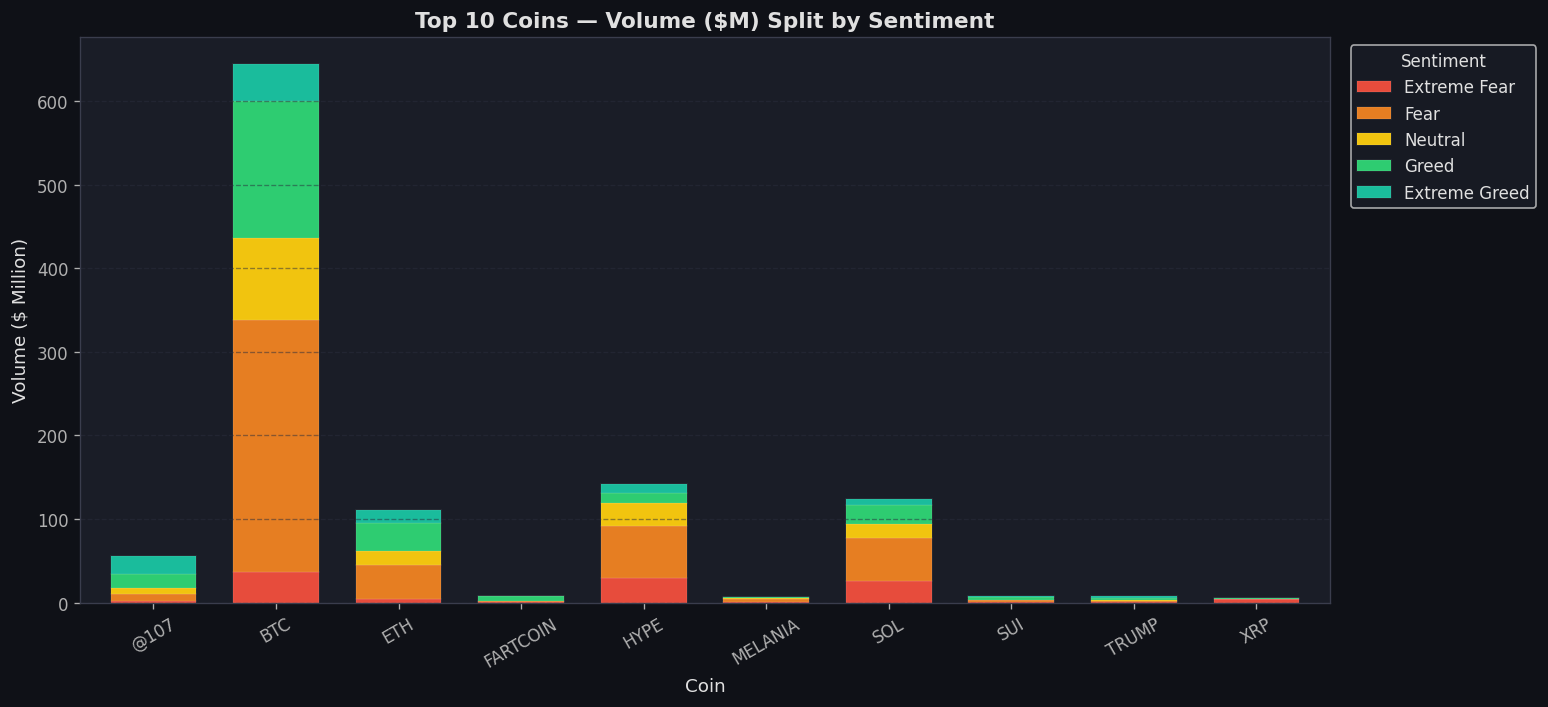

In [40]:
# Top 10 coins by volume
top_coins = merged.groupby('Coin')['Size_USD'].sum().nlargest(10).index

coin_sent = (
    merged[merged['Coin'].isin(top_coins)]
    .groupby(['Coin','classification'], observed=True)['Size_USD']
    .sum().unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER)
    / 1e6  # convert to millions
)

fig, ax = plt.subplots(figsize=(13, 6))
coin_sent.plot(
    kind='bar', stacked=True,
    color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER],
    ax=ax, edgecolor='#ffffff11', width=0.7
)
ax.set_title('Top 10 Coins — Volume ($M) Split by Sentiment', fontweight='bold')
ax.set_xlabel('Coin')
ax.set_ylabel('Volume ($ Million)')
ax.legend(title='Sentiment', facecolor='#1a1d27', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('/content/fig_coins.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()


## 12. Statistical Significance — ANOVA Test

In [41]:
# One-way ANOVA: does sentiment significantly affect PnL?
groups = [
    closed[closed['classification'] == s]['Closed_PnL'].values
    for s in SENTIMENT_ORDER
]

f_stat, p_val = stats.f_oneway(*groups)
print(f"One-Way ANOVA — F-statistic: {f_stat:.4f}, p-value: {p_val:.6f}")
if p_val < 0.05:
    print(" Result: Statistically SIGNIFICANT difference in PnL across sentiment phases (p < 0.05)")
else:
    print(" Result: No statistically significant difference (p ≥ 0.05)")

# Kruskal-Wallis (non-parametric)
h_stat, p_kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis H: {h_stat:.4f}, p-value: {p_kw:.6f}")
if p_kw < 0.05:
    print(" Kruskal-Wallis: Significant median PnL differences across sentiments")


One-Way ANOVA — F-statistic: 10.5656, p-value: 0.000000
 Result: Statistically SIGNIFICANT difference in PnL across sentiment phases (p < 0.05)

Kruskal-Wallis H: 786.4754, p-value: 0.000000
 Kruskal-Wallis: Significant median PnL differences across sentiments


## 13. Summary Insights Table

In [46]:
# ── Final summary ─────────────────────────────────────────────────────────
summary = pnl_by_sent[['Mean_PnL','Win_Rate_%','Trade_Count']].copy()
summary['Avg_Trade_Size_$K'] = (vol_by_sent['Avg_Trade_Size'] / 1000).round(1)
summary['Long_%'] = pos_mix['Long_%']


print("                  COMPLETE SENTIMENT PERFORMANCE SUMMARY")
print("-" * 75)
display(summary)

print("\n KEY TAKEAWAYS:")
best_pnl = summary['Mean_PnL'].idxmax()
best_wr  = summary['Win_Rate_%'].idxmax()
highest_size = summary['Avg_Trade_Size_$K'].idxmax()
print(f"  • Highest mean PnL per trade:  {best_pnl} (${summary.loc[best_pnl,'Mean_PnL']:,.2f})")
print(f"  • Highest win rate:            {best_wr} ({summary.loc[best_wr,'Win_Rate_%']:.1f}%)")
print(f"  • Largest avg position size:   {highest_size} (${summary.loc[highest_size,'Avg_Trade_Size_$K']:.1f}K)")


                  COMPLETE SENTIMENT PERFORMANCE SUMMARY
---------------------------------------------------------------------------


,Mean_PnL,Win_Rate_%,Trade_Count,Avg_Trade_Size_$K,Long_%
classification,,,,,
Extreme Fear,69.86,75.5,10094,5.3,65.2
Fear,115.18,87.6,29652,7.8,59.7
Neutral,71.20,82.4,18159,4.8,60.0
Greed,71.47,77.0,24939,5.7,43.0
Extreme Greed,130.21,89.2,20853,3.1,43.5



 KEY TAKEAWAYS:
  • Highest mean PnL per trade:  Extreme Greed ($130.21)
  • Highest win rate:            Extreme Greed (89.2%)
  • Largest avg position size:   Fear ($7.8K)
